# Inductive Biases

This notebook was authored by John F. Wu and produced as part of a lecture delivered to the NASA AI/ML STIG.


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


# Generate synthetic transiting exoplanet light curves

We will mock up very simple light curves, of which some fraction will be pure Gaussian noise, and the rest will contain a "transit" signal.

![](https://blog.zooniverse.org/wp-content/uploads/2015/07/screen-shot-2015-07-08-at-2-13-06-pm.png?w=672&h=332&crop=1)

Credit: [The Zooniverse Blog](https://blog.zooniverse.org/2015/07/08/introducing-the-planet-hunters-educators-guide/)

This is a rather minimal rendition of a light curve with a transiting exoplanet. When a star passes in front of a star, the observed flux will decrease. Our synthetic data will be even more simple: every transit will be a constant (rather than a trapezoid-like) dip, and all transit depths and durations will be perfectly constant.


In [2]:
class TransitDataset(Dataset):
    def __init__(
        self,
        seq_len: int = 100,
        transit_width: int = 10,
        transit_depth: float = 1.5,
        noise_std: float = 0.3,
        frac_transit: float = 0.5,
        num_samples: int = 5000,
        random_seed: int = 42
    ):
        """Synthetic transit light curve dataset generator.
        """

        self.data = []
        self.labels = []

        # store physical parameters
        self.seq_len = seq_len
        self.noise_std = noise_std
        self.transit_depth = transit_depth
        self.transit_width = transit_width
        self.frac_transit = frac_transit

        # set random seed for reproducability
        self.rng = np.random.default_rng(random_seed)

        # generate all data on initialization
        for i in range(num_samples):
            flux = self.rng.normal(0, self.noise_std, size=(1, seq_len)).astype(np.float32)

            # populate transits
            if self.rng.random() < self.frac_transit:
                label = 1

                # ensure transit is fully contained
                start = self.rng.integers(0, self.seq_len - self.transit_width)
                flux[0, start : start + self.transit_width] -= self.transit_depth
            else:
                label = 0

            # store variables
            self.data.append(torch.from_numpy(flux))
            self.labels.append(torch.tensor(label, dtype=torch.float32))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [3]:
# create the dataset with just 5 samples
ds = TransitDataset(num_samples=5, frac_transit=0.3, random_seed=42, transit_depth=1.0)

In [4]:
# show a single item
next(iter(ds))

(tensor([[ 0.0914, -0.3120,  0.2251,  0.2822, -0.5853, -0.3907,  0.0384, -0.0949,
          -0.0050, -0.2559,  0.2638,  0.2333,  0.0198,  0.3382,  0.1403, -0.2578,
           0.1106, -0.2877,  0.2635, -0.0150, -0.0555, -0.2043,  0.3668, -0.0464,
          -0.1285, -0.1056,  0.1597,  0.1096,  0.1238,  0.1292,  0.6425, -0.1219,
          -0.1537, -0.2441,  0.1848,  0.3387, -0.0342, -0.2520, -0.2473,  0.1952,
           0.2230,  0.1629, -0.1997,  0.0696,  0.0350,  0.0656,  0.2614,  0.0671,
           0.2037,  0.0203,  0.0867,  0.1894, -0.4371, -0.0959, -0.1411, -0.1917,
          -0.0825,  0.4485, -0.2597,  0.2905, -0.5049, -0.1005,  0.0488,  0.1759,
           0.2134,  0.2380, -0.1046, -0.1387, -0.7426, -1.0574, -1.3827, -1.3400,
          -1.2758, -0.8509, -0.9573, -0.7929, -1.1282, -0.9524,  0.1877, -0.0928,
           0.1370, -0.1986, -0.1089, -0.1145, -0.3588,  0.1461, -0.1408,  0.0037,
           0.1442,  0.1340,  0.1996, -0.0295, -0.1270, -0.0239, -0.5062, -0.4341,
          -0.396

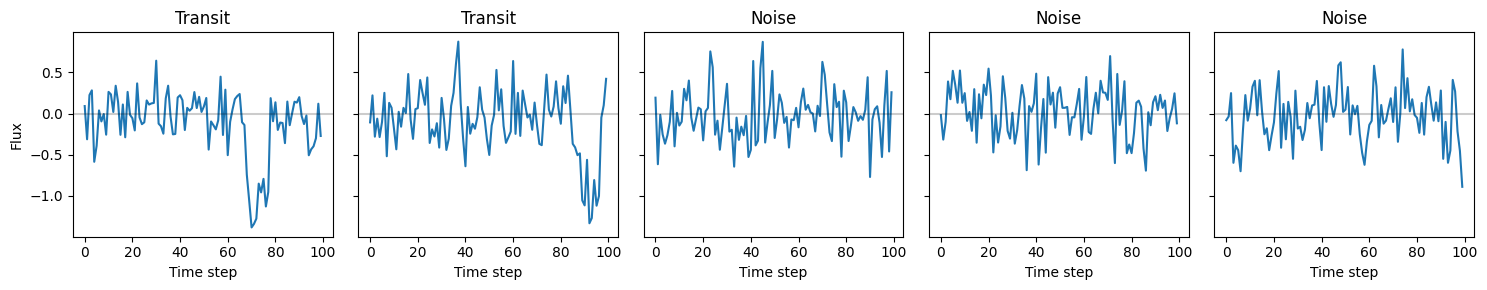

In [5]:
# visualize a few examples
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
ds_iter = iter(ds)

for ax in axes.flat:
    data, label = next(ds_iter)

    ax.plot(data.squeeze())
    title = "Transit" if label else "Noise"
    ax.set_title(title)
    ax.set_xlabel("Time step")
    if ax == axes[0]: ax.set_ylabel("Flux")

    ax.axhline(0, color='k', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

# What *kind* of problem are we trying to solve?

Remember that we want to specify some kind of *inductive bias* that aligns with the sort of problem we'd like to solve. Here are several neural network architectures alongside their inductive biases:
* **Multilayer perceptron (MLP)**. Each flux at each time bin is an independent feature.
* **Convolutional Neural Network (CNN)**. Learns local (short-range) temporal features; invariant to *which* time bin any feature is detected.
* **Recurrent Neural Network (RNN)**. Learns an internal representation for each time that depends on the previous time step.
* **Transformer**. Contains an "Attention" mechanism that is useful for modeling long-range temporal dependencies. Features also do not know about the time bin, although learnable positional embeddings can be included to break this invariance.

In [6]:
# make dataset and Pytorch dataloader with lower SNR
dataset = TransitDataset(num_samples=5000, frac_transit=0.5, random_seed=42, noise_std=0.3, transit_depth=0.5)
train_size = int(0.8 * len(dataset))

# randomly split into 80% training, 20% validation/testing
train_data, test_data = torch.utils.data.random_split(
    dataset, [train_size, len(dataset)-train_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [7]:

class SimpleMLP(nn.Module):
    def __init__(self, seq_len=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                 # (B, 1, 100) -> (B, 100)
            nn.Linear(seq_len, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)              #
        )

    def forward(self, x):
        return self.net(x)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2), # (B, 1, 100) -> (B, 16, 100)
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # -> (B, 16, 50)
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2),# -> (B, 32, 50)
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # -> (B, 32, 25)
            nn.Flatten(),                 # -> (B, 800)
            nn.Linear(32 * 25, 1)
        )

    def forward(self, x):
        return self.net(x)

class SimpleRNN(nn.Module):
    def __init__(self, gated=False):
        super().__init__()
        if gated: # remember/forget gate
            self.rnn = nn.GRU(input_size=1, hidden_size=64, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size=1, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        # x is (B, 1, 100); RNN needs transpose (B, Seq, Feature) -> (B, 100, 1)
        x = x.permute(0, 2, 1)
        out, h_n = self.rnn(x)

        # return final state
        return self.fc(h_n.squeeze(0))

class SimpleTransformer(nn.Module):
    def __init__(self, seq_len=100, include_pos_embed=False):
        super().__init__()
        self.d_model = 32

        # input embedding
        self.input_proj = nn.Linear(1, self.d_model)

        # learnable position embeddings? (default False)
        if include_pos_embed:
            self.pos_embed = nn.Parameter(torch.randn(1, seq_len, self.d_model))
        else:
            self.pos_embed = 0

        # single-headed attention, encoder only
        layer = nn.TransformerEncoderLayer(d_model=self.d_model, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=1)

        # single output
        self.fc = nn.Linear(self.d_model, 1)

    def forward(self, x):
        # x is (B, 1, 100) -> (B, 100, 1)
        x = x.permute(0, 2, 1)

        x = self.input_proj(x) + self.pos_embed
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.fc(x)

# Problem formulation: Can we classify whether a light curve contains a transit?

We set up the dataset with inputs (of shape `(1, 100)`) and with binary categorical labels (`True` for a transit, `False` for noise).



We train a model that minimizes **binary cross-entropy with logits**:

$$
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N
\Big[
\underbrace{\color{blue}{y_i \log \sigma(z_i)}}_{\text{True value = 1}}
+
\underbrace{\color{darkorange}{(1 - y_i)\log(1 - \sigma(z_i))}}_{\text{True value = 0}}
\Big]
$$

where:
- $ z_i = f_\theta(x_i) $ are the unnormalized output scores for the "True" and "False" predictions, i.e. the **logits** from the model,
- $ \sigma(z) = \frac{1}{1 + e^{-z}} $ is the sigmoid function,
- $ y_i \in \{0,1\} $ are the true labels.

Binary cross-entropy looks like this for predictions $p_i=\sigma(z_i)$, conditioned on whether the true value $y_i$ is 1 or 0.

![](https://www.pinecone.io/_next/image/?url=https%3A%2F%2Fcdn.sanity.io%2Fimages%2Fvr8gru94%2Fproduction%2F54c97fda8af4dccc23d58bd14cd95802df6f1e49-393x272.png&w=828&q=75)


In practice, the training algorithm looks iterates over each epoch (single pass through training data set):
1. Forward pass: compute logits $z$.
2. Compute loss $\mathcal{L}$ using [`BCEWithLogitsLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) from Pytorch
3. Backpropagation: update parameters via [`AdamW`](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html) optimizer.
4. Validation: compute accuracy with threshold $p > 0.5$.



In [8]:
def train_and_evaluate(model, train_loader, test_loader, epochs=20):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    accuracies = []

    for epoch in range(epochs):
        # train
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x).squeeze()
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # validate
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x).squeeze()
                valid_loss += criterion(logits, y).item()
                preds = (torch.sigmoid(logits) > 0.5).float()
                correct += (preds == y).sum().item()
                total += y.size(0)

        acc = correct / total
        print(f"Epoch {epoch+1: >2d} | Train Loss: {train_loss/len(train_loader):.4f} | Valid: {valid_loss/len(test_loader):.4f} | Valid Acc: {acc:.2%}")

        accuracies.append(acc)
    return accuracies


def count_trainable_parameters(model):
    """Helper function to count nubmer of trainable params
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:

print("1. MLP")
mlp_model = SimpleMLP()
print(f"    N params: {count_trainable_parameters(mlp_model)}")
mlp_acc = train_and_evaluate(mlp_model, train_loader, test_loader)

print("\n2. CNN")
cnn_model = SimpleCNN()
print(f"    N params: {count_trainable_parameters(cnn_model)}")
cnn_acc = train_and_evaluate(cnn_model, train_loader, test_loader)

print("\n3. RNN")
rnn_model = SimpleRNN()
print(f"    N params: {count_trainable_parameters(rnn_model)}")
rnn_acc = train_and_evaluate(rnn_model, train_loader, test_loader)

print("\n4. Transformer")
transformer_model = SimpleTransformer()
print(f"    N params: {count_trainable_parameters(transformer_model)}")
transformer_acc = train_and_evaluate(transformer_model, train_loader, test_loader);



1. MLP
    N params: 10689
Epoch  1 | Train Loss: 0.6447 | Valid: 0.5510 | Valid Acc: 76.70%
Epoch  2 | Train Loss: 0.4422 | Valid: 0.4424 | Valid Acc: 79.80%
Epoch  3 | Train Loss: 0.3622 | Valid: 0.4056 | Valid Acc: 81.90%
Epoch  4 | Train Loss: 0.3018 | Valid: 0.3602 | Valid Acc: 83.90%
Epoch  5 | Train Loss: 0.2391 | Valid: 0.3092 | Valid Acc: 86.40%
Epoch  6 | Train Loss: 0.1770 | Valid: 0.2664 | Valid Acc: 88.50%
Epoch  7 | Train Loss: 0.1300 | Valid: 0.2459 | Valid Acc: 90.20%
Epoch  8 | Train Loss: 0.0944 | Valid: 0.2376 | Valid Acc: 90.90%
Epoch  9 | Train Loss: 0.0683 | Valid: 0.2427 | Valid Acc: 91.20%
Epoch 10 | Train Loss: 0.0491 | Valid: 0.2573 | Valid Acc: 90.20%
Epoch 11 | Train Loss: 0.0352 | Valid: 0.2544 | Valid Acc: 91.90%
Epoch 12 | Train Loss: 0.0239 | Valid: 0.2652 | Valid Acc: 90.90%
Epoch 13 | Train Loss: 0.0168 | Valid: 0.2808 | Valid Acc: 90.60%
Epoch 14 | Train Loss: 0.0116 | Valid: 0.2845 | Valid Acc: 90.80%
Epoch 15 | Train Loss: 0.0083 | Valid: 0.2924 | V

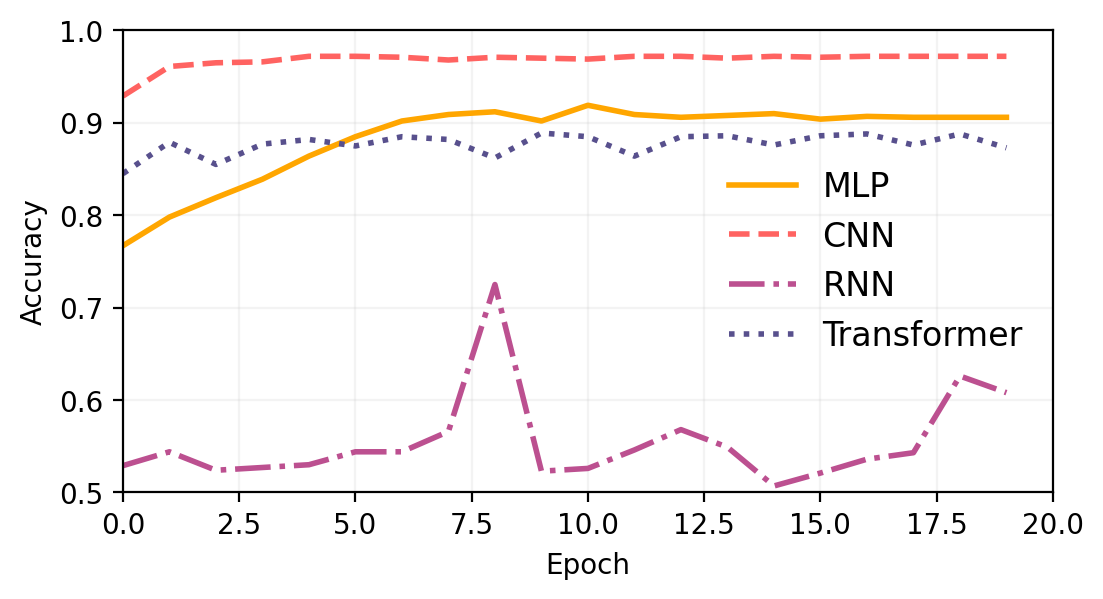

In [13]:
plt.figure(figsize=(6, 3), dpi=200)

plt.plot(mlp_acc, c="#ffa600", lw=2, ls="-", label="MLP")
plt.plot(cnn_acc, c="#ff6361", lw=2, ls="--", label="CNN")
plt.plot(rnn_acc, c="#bc5090", lw=2, ls="-.", label="RNN")
plt.plot(transformer_acc, c="#58508d", lw=2, ls=":", label="Transformer")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1)
plt.xlim(0, 20)
plt.legend(loc="center right", fontsize=12, framealpha=0)
plt.grid(alpha=0.15)
